In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
from scipy.signal.windows import tukey
from pathlib import Path

In [12]:
""" Legge un file .wav e ne visualizza la forma d'onda."""

samplerate, data = wavfile.read('data/note_91.wav')

data_sx = data[:, 0]  # Canale sinistro
data_dx = data[:, 1]  # Canale destro

n = len(data)

fft_sx = np.fft.fft(data_sx)
fft_dx = np.fft.fft(data_dx)

power_spectrum_sx = np.abs(fft_sx[:n//2])**2
power_spectrum_dx = np.abs(fft_dx[:n//2])**2

frequencies = np.fft.fftfreq(n, d=1/samplerate)[:n//2]

/var/folders/jm/brl1kdcn5mv6s_f18tvp6lsh0000gn/T/ipykernel_6504/3248049063.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read('data/note_91.wav')


In [13]:
def window_organ_signal(signal, sample_rate, start_sec, end_sec, fade_fraction=0.1):
    """
    Ritaglia il segnale e applica una finestra di Tukey per evitare click e leakage.
    
    :param signal: Array numpy del segnale audio.
    :param sample_rate: Frequenza di campionamento (es. 44100).
    :param start_sec: Secondo di inizio del taglio.
    :param end_sec: Secondo di fine del taglio.
    :param fade_fraction: Percentuale della finestra dedicata al fade (0-1).
    :return: Segnale ritagliato e finestrato.
    
    """
    # 1. Ritaglio temporale
    start_sample = int(start_sec * sample_rate)
    end_sample = int(end_sec * sample_rate)
    trimmed_signal = signal[start_sample:end_sample]
    
    # 2. Creazione della finestra di Tukey
    # fade_fraction definisce quanto i bordi sono smussati.
    # Se 0 è una rettangolare, se 1 è una finestra di Hann.
    win = tukey(len(trimmed_signal), alpha=fade_fraction)
    
    # 3. Applicazione
    windowed_signal = trimmed_signal * win
    
    return windowed_signal

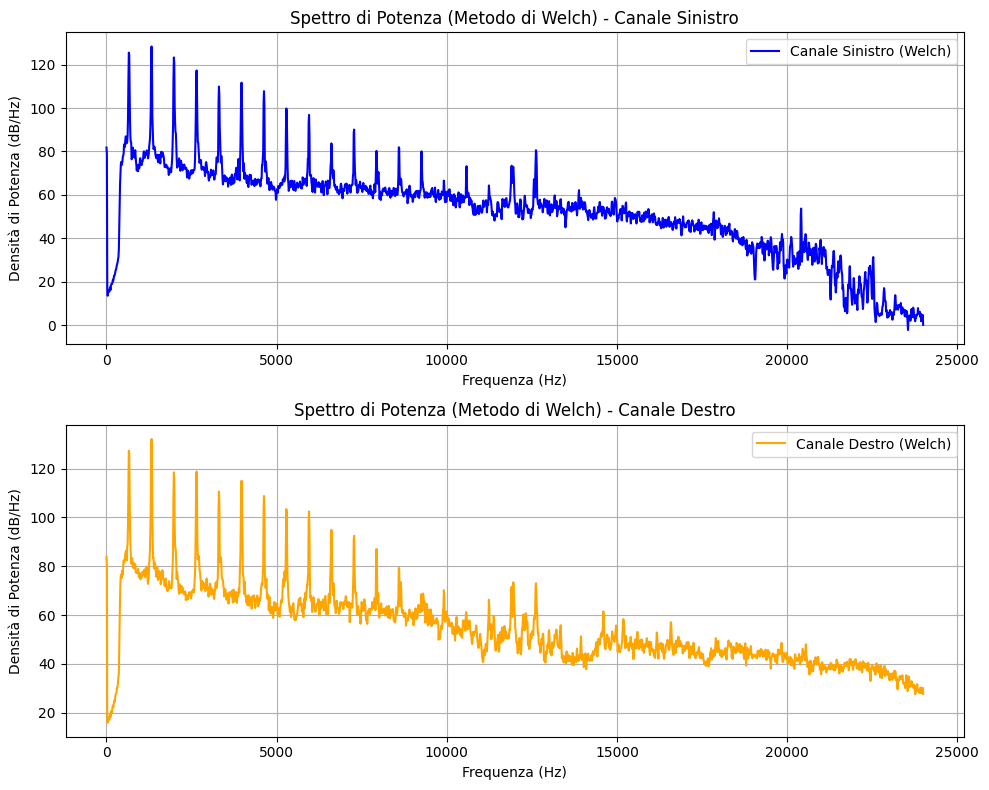

In [ ]:
from scipy.signal import welch

# 1. Utilizza la tua funzione per ritagliare e finestrare una porzione del segnale.
# Esempio: analizziamo il segnale dal secondo 0.5 al secondo 2.0
start_sec = 0.5 
end_sec = 1.0    

data_sx_windowed = window_organ_signal(data_sx, samplerate, start_sec, end_sec)
data_dx_windowed = window_organ_signal(data_dx, samplerate, start_sec, end_sec)

# 2. Calcolo dello spettro di potenza (PSD) tramite il metodo di Welch.
# Questo metodo divide il segnale in segmenti sovrapposti (numero di segmenti è nperseg) e ne fa la media, restituendo uno spettro molto più leggibile.
nperseg = 4096 # Lunghezza del segmento per la FFT (più è alto, maggiore è la risoluzione in frequenza)

# Calcolo dello spettro di potenza per entrambi i canali tramite welch che aplica già fft
freqs_sx, psd_sx = welch(data_sx_windowed, fs=samplerate, nperseg=nperseg)
freqs_dx, psd_dx = welch(data_dx_windowed, fs=samplerate, nperseg=nperseg)

# 3. Visualizzazione degli spettri in Decibel (dB)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Canale Sinistro
axes[0].plot(freqs_sx, 10 * np.log10(psd_sx), label='Canale Sinistro (Welch)', color='blue')
axes[0].set_title('Spettro di Potenza (Metodo di Welch) - Canale Sinistro')
axes[0].set_xlabel('Frequenza (Hz)')
axes[0].set_ylabel('Densità di Potenza (dB/Hz)')
axes[0].grid(True)
axes[0].legend()    

# Canale Destro
axes[1].plot(freqs_dx, 10 * np.log10(psd_dx), label='Canale Destro (Welch)', color='orange')
axes[1].set_title('Spettro di Potenza (Metodo di Welch) - Canale Destro')
axes[1].set_xlabel('Frequenza (Hz)')
axes[1].set_ylabel('Densità di Potenza (dB/Hz)')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

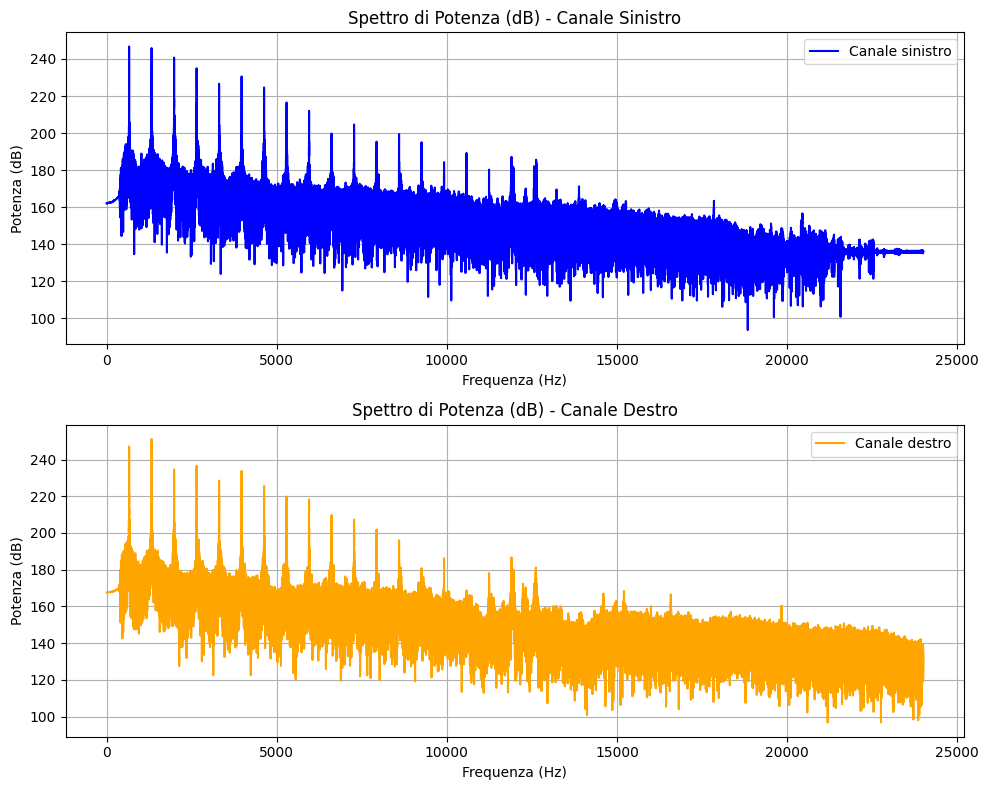

In [4]:
def confronta_spettri_nota(file_path, start_s=0.5, end_s=2.5):
    # 1. Caricamento "manuale"
    samplerate, data = wavfile.read(file_path)
    
    # Conversione float (per evitare overflow e gestire bene i calcoli)
    if data.dtype == np.int16:
        data = data / 32768.0

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].plot(frequencies, 10 * np.log10(power_spectrum_sx), label='Canale sinistro', color='blue')
axes[0].set_title('Spettro di Potenza (dB) - Canale Sinistro')
axes[0].set_xlabel('Frequenza (Hz)')
axes[0].set_ylabel('Potenza (dB)')
axes[0].grid(True)
axes[0].legend()    
axes[1].plot(frequencies, 10 * np.log10(power_spectrum_dx), label='Canale destro', color='orange')
axes[1].set_title('Spettro di Potenza (dB) - Canale Destro')
axes[1].set_xlabel('Frequenza (Hz)')
axes[1].set_ylabel('Potenza (dB)')
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()
plt.show()

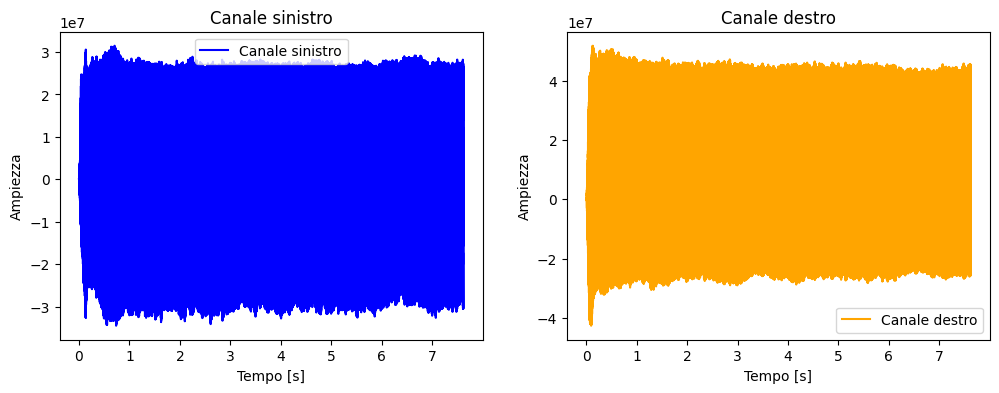

In [5]:
""" Calcola il tempo in secondi per ogni campione e crea un array di tempo corrispondente alla forma d'onda."""

    # 3. Definiamo noi la logica della FFT e Power Spectrum
    # Invece di usare funzioni pronte, facciamo i passaggi base
    def calcola_psd_base(segno, fs):
        N = len(segno)
        # Trasformata di Fourier
        fft_complex = np.fft.fft(segno)
        # Prendiamo solo la prima metà (simmetria)
        metà = N // 2
        # Modulo al quadrato (Power) e normalizzazione base per la lunghezza
        psd = (np.abs(fft_complex[:metà])**2) / N
        # Vettore frequenze: k * fs / N
        freqs = np.array([k * fs / N for k in range(metà)])
        return freqs, psd

    # Calcoliamo i 4 spettri
    f_orig, psd_sx_orig = calcola_psd_base(sig_sx_orig, samplerate)
    _,      psd_dx_orig = calcola_psd_base(sig_dx_orig, samplerate)
    f_cut,  psd_sx_cut  = calcola_psd_base(sig_sx_cut, samplerate)
    _,      psd_dx_cut  = calcola_psd_base(sig_dx_cut, samplerate)

    # 4. Creazione dei 4 subplots
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Analisi Spettrale: {Path(file_path).name}", fontsize=14)

    # Definiamo una lista di dati per iterare facilmente sui grafici
    dati_plot = [
        (f_orig, psd_sx_orig, "SX Originale", "blue"),
        (f_orig, psd_dx_orig, "DX Originale", "red"),
        (f_cut,  psd_sx_cut,  "SX Tagliato/Finestrato", "darkblue"),
        (f_cut,  psd_dx_cut,  "DX Tagliato/Finestrato", "darkred")
    ]

    for i, (f, p, titolo, colore) in enumerate(dati_plot):
        ax = axs[i//2, i%2]
        # Usiamo il logaritmo per vedere meglio le armoniche (decibel relativi)
        ax.plot(f, 10 * np.log10(p + 1e-12), color=colore) 
        ax.set_title(titolo)
        ax.set_xlim(0, 4000) # L'organo raramente ha armoniche utili sopra i 4kHz
        ax.grid(True, alpha=0.3)
        if i >= 2: ax.set_xlabel("Frequenza (Hz)")
        if i % 2 == 0: ax.set_ylabel("Potenza (dB)")

    plt.tight_layout()
    plt.show()


confronta_spettri_nota('data/note_91.wav')